<a href="https://colab.research.google.com/github/mhawkes2/AML/blob/main/Hawkes_%26_Fishman_House_Prices_Advanced_Regression_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1) Import Libraries & Datasets

In [ ]:
import numpy as np, pandas as pd, sklearn, seaborn as sns, matplotlib.pyplot as plt
from scipy import stats

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBRegressor
import joblib

sns.set(context='notebook', style='whitegrid')

test_filepath='/content/test.csv'
train_filepath='/content/train.csv'

test_df=pd.read_csv(test_filepath)
train_df=pd.read_csv(train_filepath)

# 2) Exploratory Data Analysis


Numeric columns (37): ['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2'] ...
Categorical columns (43): ['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1'] ...


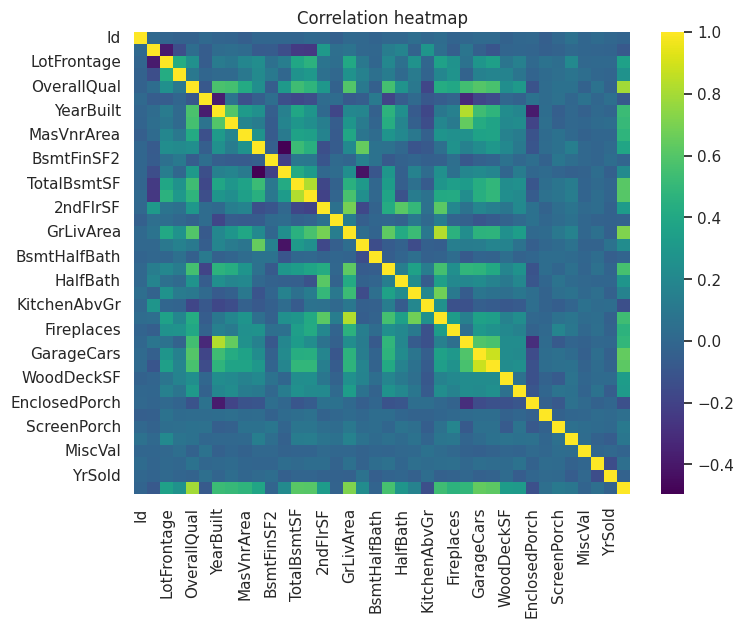

,missing_rate
PoolQC,99.5%
MiscFeature,96.3%
Alley,93.8%
Fence,80.8%
MasVnrType,59.7%
FireplaceQu,47.3%
LotFrontage,17.7%
GarageQual,5.5%
GarageFinish,5.5%
GarageType,5.5%


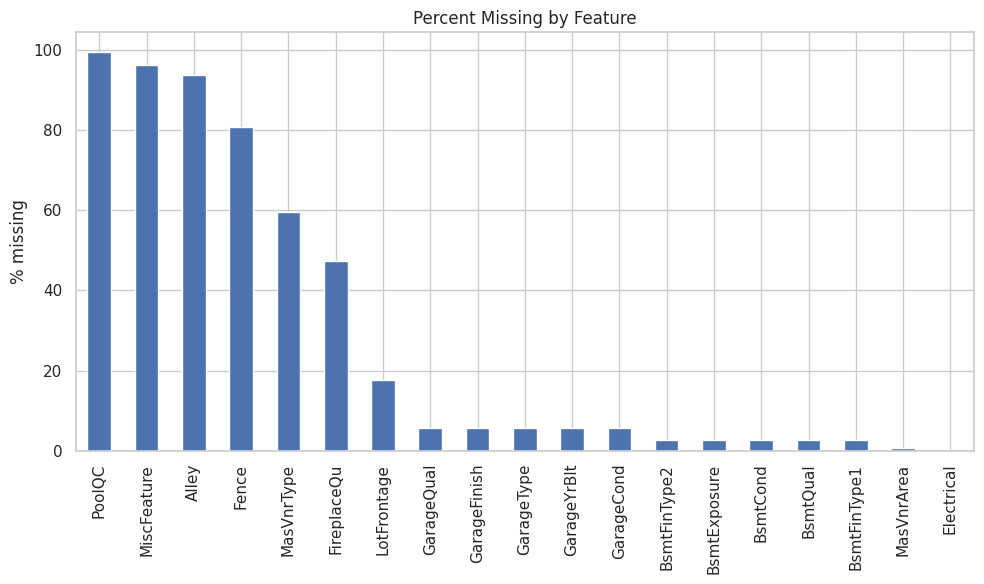

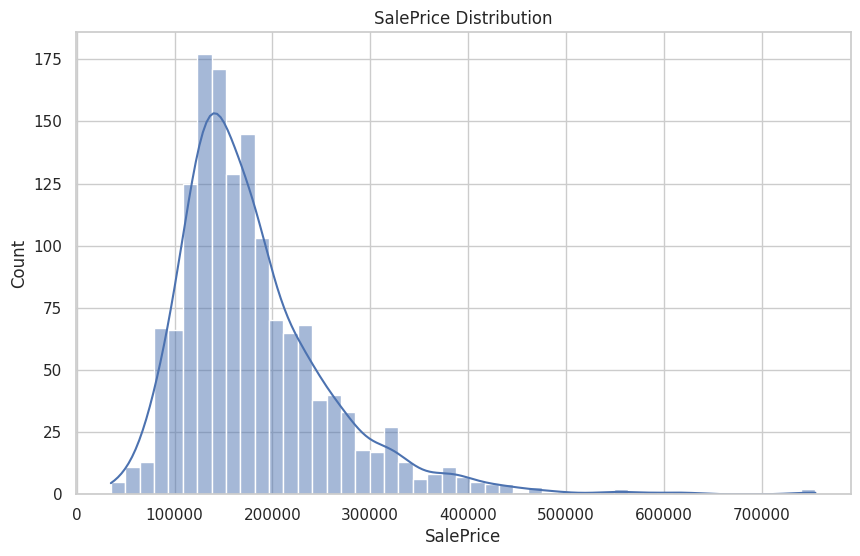

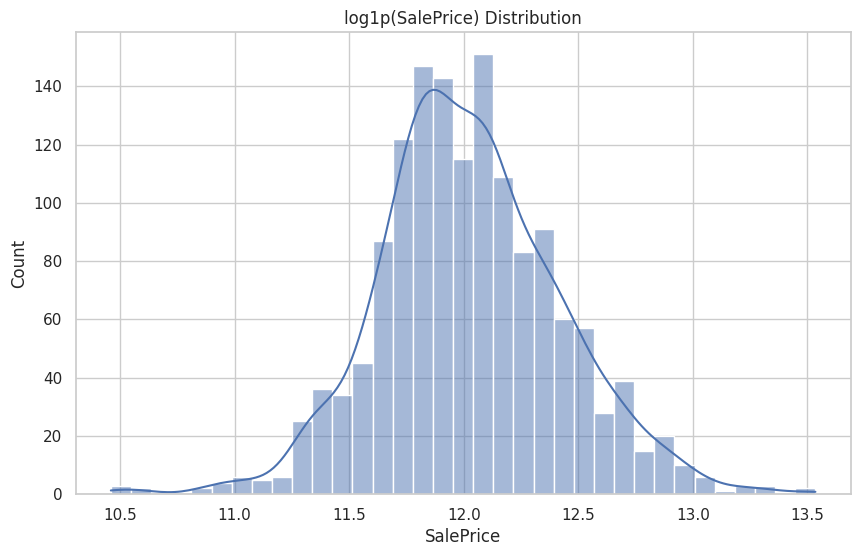

In [ ]:
plt.rcParams["figure.figsize"] = (10, 6)

numeric_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = train_df.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_cols.remove('Id')

print(f"\nNumeric columns ({len(numeric_cols)}):", numeric_cols[:10], "..." if len(numeric_cols) > 10 else "")
print(f"Categorical columns ({len(cat_cols)}):", cat_cols[:10], "..." if len(cat_cols) > 10 else "")

# Correlation matrix
corr = train_df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap='viridis')
ax.set_title('Correlation heatmap')
plt.show()

# Missing data overview
mis = train_df.isnull().mean().sort_values(ascending=False)
mis_nonzero = mis[mis > 0]
display(pd.DataFrame({"missing_rate": mis_nonzero}).style.format({"missing_rate": "{:.1%}"}))

plt.figure()
(mis_nonzero*100).plot(kind="bar")
plt.title("Percent Missing by Feature")
plt.ylabel("% missing")
plt.tight_layout()
plt.show()

# SalePrice distribution
fig, ax = plt.subplots()
sns.histplot(train_df["SalePrice"].dropna(), kde=True, ax=ax)
ax.set_title("SalePrice Distribution")

fig, ax = plt.subplots()
sns.histplot(np.log1p(train_df["SalePrice"].dropna()), kde=True, ax=ax)
ax.set_title("log1p(SalePrice) Distribution")
plt.show()

# 3) Feature Engineering

In [ ]:
for df in [train_df, test_df]:
  # Total features
  df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
  df["TotalBath"] = df["FullBath"] + 0.5*df["HalfBath"] + df["BsmtFullBath"] + 0.5*df["BsmtHalfBath"]
  df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
  df["TotalRooms"] = df["TotRmsAbvGrd"] + df["FullBath"] + df["HalfBath"]

  # Quality features
  qual_map = {"Ex":5,"Gd":4,"TA":3,"Fa":2,"Po":1,np.nan:0}
  for col in ["ExterQual","ExterCond","BsmtQual","BsmtCond","HeatingQC","KitchenQual","GarageQual","GarageCond","FireplaceQu"]:
    if col in df.columns:
      df[col+"_num"] = df[col].map(qual_map).fillna(0)
  qual_feats = [c for c in df.columns if c.endswith("_num")]
  df["MeanQualScore"] = df[qual_feats].mean(axis=1)
  df["QualitySize"] = df["OverallQual"] * df["GrLivArea"]
  df["QualityTotalSF"] = df["OverallQual"] * df["TotalSF"]

  # Age/time
  df["HouseAge"] = df["YrSold"] - df["YearBuilt"]
  df["RemodAge"] = df["YrSold"] - df["YearRemodAdd"]

  # Ratios
  df["GrLiv_to_LotArea"] = df["GrLivArea"] / (df["LotArea"] + 1)
  df["Bsmt_to_TotalSF"] = df["TotalBsmtSF"] / (df["TotalSF"] + 1)
  df["Garage_to_GrLiv"] = df["GarageArea"] / (df["GrLivArea"] + 1)

  # Logs for skew
  for c in ["GrLivArea","LotArea","TotalBsmtSF","1stFlrSF","GarageArea","TotalSF"]:
    df["log_"+c] = np.log1p(df[c])

# 4) Determining the Best Model

In [ ]:
# Target + features
X = train_df.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y = train_df['SalePrice']

# Numeric-only subset for simplicity
X = X.select_dtypes(include=[np.number]).fillna(0)
numeric_features = X.columns.tolist()

# Preprocess
preprocess = ColumnTransformer([('num', StandardScaler(), numeric_features)],
                               remainder='drop')

# Pipelines for each model
pipelines = {
    'Linear': Pipeline([ # Linear regression that tries to fit a plane to the data
        ('prep', preprocess),
        ('model', LinearRegression())
    ]),

    'Ridge': Pipeline([ # Similar to linear regression, but prevents overfitting through penalties
        ('prep', preprocess),
        ('model', Ridge(random_state=42))
    ]),

    'RandomForest': Pipeline([ # Create many decision trees to reduce overfitting
        ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
    ]),

    'XGBoost': Pipeline([ # Builds decision trees sequentially, where each new one fixes the errors in the past ones
        ('model', XGBRegressor(
            random_state=42,
            n_estimators=500,
            learning_rate=0.1,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            objective='reg:squarederror',
            tree_method='hist',
            n_jobs=-1
        ))
    ])
}

# Train-test split to determine what model is most effective
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Predict using each model to determine what is best
rmse_scores = {}
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    rmse_scores[name] = rmse
    print(f'{name}: RMSE = {rmse:.4f}')

# Best model
best = min(rmse_scores, key=rmse_scores.get)
print(f'\nBest model: {best} (RMSE={rmse_scores[best]:.4f})')

Linear: RMSE = 32177.2938
Ridge: RMSE = 32223.1353
RandomForest: RMSE = 29629.0857
XGBoost: RMSE = 26831.2093

Best model: XGBoost (RMSE=26831.2093)


# 5) Hyperparameter Tuning & Prediction

In [ ]:
RANDOM_STATE = 42

# Select features and target variable
X = train_df.drop(['SalePrice', 'Id'], axis=1, errors='ignore')
y = train_df['SalePrice']

# Separate numeric and categorical columns
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Fill missing values for numeric and categorical columns
X[num_cols] = X[num_cols].fillna(0)
X[cat_cols] = X[cat_cols].fillna('Missing')

# ColumnTransformer for preprocessing, numeric data stays the same, categorical data is encoded
preprocess = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),  # numeric columns unchanged
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

# Preprocess data
X_processed = preprocess.fit_transform(X)

# Train-validation split for early stopping
X_train, X_valid, y_train, y_valid = train_test_split(
    X_processed, y, test_size=0.2, random_state=RANDOM_STATE
)

# XGBoost model
xgb = XGBRegressor(
    random_state=RANDOM_STATE,
    objective='reg:squarederror',
    tree_method='hist',
    n_jobs=-1
)

# Parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': [300, 500, 700],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [4, 6, 8],
    'subsample': [0.7, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

# Cross-validation
cv = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

# RandomizedSearchCV
rand_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=15,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1
)

# Fit XGBoost on training data using early stopping on validation set
rand_search.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    verbose=False
)

# Display best hyperparameters and CV score
print("Best parameters:", rand_search.best_params_)
print("Best CV RMSE:", -rand_search.best_score_)

# Retrain best model on all data
X_processed_full = preprocess.transform(X)  # all data
best_model = rand_search.best_estimator_
best_model.fit(X_processed_full, y)

# Prepare and preprocess test data
X_test = test_df.drop(['Id'], axis=1, errors='ignore')
X_test[num_cols] = X_test[num_cols].fillna(0)
X_test[cat_cols] = X_test[cat_cols].fillna('Missing')
X_test_processed = preprocess.transform(X_test)

# Predict
kaggle_preds = best_model.predict(X_test_processed)

# Generate submissions file
submission = pd.DataFrame({
    'Id': test_df['Id'].values,
    'SalePrice': kaggle_preds
})
submission.to_csv('submission.csv', index=False)
submission.head()

Fitting 3 folds for each of 15 candidates, totalling 45 fits
Best parameters: {'subsample': 0.7, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV RMSE: 29351.907552083332


,Id,SalePrice
0,1461,117662.539062
1,1462,161923.406250
2,1463,183242.812500
3,1464,194952.875000
4,1465,178962.468750


# Summary

1.   We began our project with the basic steps of all projects: importing necessary libraries and loading our datasets.

2.   Next, we did some exploratory data analysis, so that we could understand our dataset and the correlation between features better.

1.   Our folliwng step was to engineer some features that we believed would be effective in our project. We created many features that combined those that came with the dataset. When testing our models, we found that many of features were highly effective, such as "QualityTotalSF" which was at the top of the feature importance list.

2.  After that, we wanted to see what model was most effective on our dataset. For simplicity, we used only the numeric features for this step. We tested four models: Linear, Ridge, Random Forest, and a new one, XGBoost, which we found to be the most effective. XGBoost is a forest-based model that sequentially creates decision trees, with each one improving off the last. This leads to an overall more accurate model.

1.   Finally, we tuned our XGBoost model using a RandomizedSearchCV strategy, which we found to be much faster than the exhaustive GridSearchCV. This strategy did not compromise effectiveness for speed. After tuning our model, we used it to predict the "SalePrice" of each house in the test dataframe. On Kaggle, the submission.csv we created received a score of 0.12660, which ranked 866th on the leaderboard.

